# Optimal Tree Structures in Decision Trees for Loan Approval Prediction

**Course: CSL7620 - Machine Learning (IIT Jodhpur)**

**Submitted By: Arjun Baidya (M25CSA006)**

This notebook contains a complete pipeline to develop a loan approval prediction system using optimized decision trees. It also addresses severe class imbalance issue in the data (10,000 approved vs 35,000 rejected loans in 45,000 applications).

**Source of Dataset**: https://www.kaggle.com/datasets/taweilo/loan-approval-prediction

## 1. Setup & Import Required Packages

In [ ]:
# Core libraries
import pandas as pd
import numpy as np

# Scikit-learn imports
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.utils import class_weight

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
import warnings
warnings.filterwarnings('ignore')
plt.style.use('default')
np.random.seed(42)

print("All packages imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Scikit-learn version: {__import__('sklearn').__version__}")

All packages imported successfully!
Pandas version: 2.2.2
NumPy version: 2.0.2
Scikit-learn version: 1.6.1


## 2. Data Loading & Initial Exploration

In [ ]:
# Loading dataset

df = pd.read_csv('loan_data.csv')
print(f"Dataset shape: {df.shape}")
print(f"Features: {df.shape[1] - 1}, Target: 1")

# Displaying basic information
print("\nDataset Info:")
print(df.info())

print("\nFirst 5 rows:")
df.head()

Dataset shape: (45000, 14)
Features: 13, Target: 1

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  int64  
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  int64  
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  int64  
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  int64  
 11  credit_score               

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1


## 3. Explore Class Imbalance Problem

Target Variable Distribution:
loan_status
0    35000
1    10000
Name: count, dtype: int64

Class Distribution Percentage:
loan_status
0    77.777778
1    22.222222
Name: proportion, dtype: float64

Class Imbalance Ratio: 3.50:1


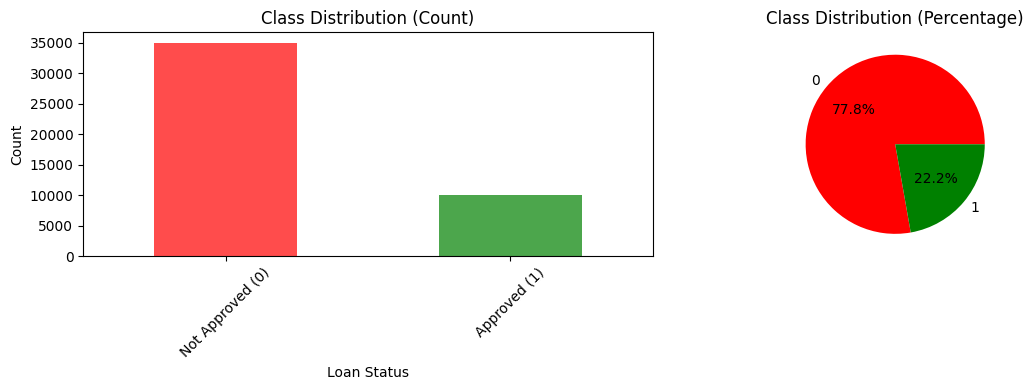


The dataset shows significant class imbalance!
This will be addressed using multiple techniques in the pipeline.


In [ ]:
# Analyzing target variable distribution
print("Target Variable Distribution:")
target_counts = df['loan_status'].value_counts()
print(target_counts)

print("\nClass Distribution Percentage:")
target_pct = df['loan_status'].value_counts(normalize=True) * 100
print(target_pct)

# Calculating imbalance ratio
imbalance_ratio = target_counts.max() / target_counts.min()
print(f"\nClass Imbalance Ratio: {imbalance_ratio:.2f}:1")

# Visualizing class distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
target_counts.plot(kind='bar', color=['red', 'green'], alpha=0.7)
plt.title('Class Distribution (Count)')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.xticks([0, 1], ['Not Approved (0)', 'Approved (1)'], rotation=45)

plt.subplot(1, 2, 2)
target_pct.plot(kind='pie', autopct='%1.1f%%', colors=['red', 'green'])
plt.title('Class Distribution (Percentage)')
plt.ylabel('')

plt.tight_layout()
plt.show()

print(f"\nThe dataset shows significant class imbalance!")
print(f"This will be addressed using multiple techniques in the pipeline.")

## 4. Data Preprocessing & Feature Engineering

In [ ]:
# Defining feature types
categorical_cols = [
    'person_gender', 'person_education', 'person_home_ownership',
    'loan_intent', 'previous_loan_defaults_on_file'
]

numerical_cols = [
    'person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
    'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
    'credit_score'
]

print(f"Categorical features ({len(categorical_cols)}): {categorical_cols}")
print(f"Numerical features ({len(numerical_cols)}): {numerical_cols}")

# Checking for missing values
print("\nMissing values check:")
missing_values = df.isnull().sum()
if missing_values.sum() == 0:
    print("No missing values found!")
else:
    print(missing_values[missing_values > 0])

# Separating features and target
X = df.drop('loan_status', axis=1).copy()
y = df['loan_status'].copy()

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

Categorical features (5): ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']
Numerical features (8): ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']

Missing values check:
No missing values found!

Feature matrix shape: (45000, 13)
Target vector shape: (45000,)


## 5. Train/Validation/Test Split (Stratified)

In [ ]:
# Stratified split to preserve class distribution
# First split: separate test set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: separate train and validation sets (64% train, 16% validation)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
)

print(f"Data splitting completed:")
print(f"  Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"  Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

# Verify class distribution is preserved
print(f"\nClass distribution verification:")
print(f"  Original: {y.value_counts(normalize=True).round(3).to_dict()}")
print(f"  Training: {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"  Validation: {y_val.value_counts(normalize=True).round(3).to_dict()}")
print(f"  Test: {y_test.value_counts(normalize=True).round(3).to_dict()}")

Data splitting completed:
  Training set: 28800 samples (64.0%)
  Validation set: 7200 samples (16.0%)
  Test set: 9000 samples (20.0%)

Class distribution verification:
  Original: {0: 0.778, 1: 0.222}
  Training: {0: 0.778, 1: 0.222}
  Validation: {0: 0.778, 1: 0.222}
  Test: {0: 0.778, 1: 0.222}


In [ ]:
# Creating preprocessing pipeline with One-Hot Encoding
print("Setting up preprocessing pipeline with One-Hot Encoding for categorical features...")

# Creating column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

# Fitting the preprocessor on training data and transform all datasets
print("\nFitting preprocessor on training data...")
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

# Getting feature names after transformation
num_feature_names = numerical_cols
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
all_feature_names = list(num_feature_names) + list(cat_feature_names)

print(f"\nPreprocessing completed!")
print(f"Original features: {len(categorical_cols) + len(numerical_cols)}")
print(f"Features after one-hot encoding: {len(all_feature_names)}")
print(f"\nCategorical feature expansion:")

for col in categorical_cols:
    encoded_cols = [f for f in cat_feature_names if f.startswith(col + '_')]
    print(f"  {col}: {len(encoded_cols) + 1} categories → {len(encoded_cols)} binary features (drop='first')")

print("\nSample of encoded feature names:")
print(f"  Numerical: {num_feature_names[:3]}")
print(f"  Categorical (sample): {list(cat_feature_names[:5])}")

Setting up preprocessing pipeline with One-Hot Encoding for categorical features...

Fitting preprocessor on training data...

Preprocessing completed!
Original features: 13
Features after one-hot encoding: 22

Categorical feature expansion:
  person_gender: 2 categories → 1 binary features (drop='first')
  person_education: 5 categories → 4 binary features (drop='first')
  person_home_ownership: 4 categories → 3 binary features (drop='first')
  loan_intent: 6 categories → 5 binary features (drop='first')
  previous_loan_defaults_on_file: 2 categories → 1 binary features (drop='first')

Sample of encoded feature names:
  Numerical: ['person_age', 'person_income', 'person_emp_exp']
  Categorical (sample): ['person_gender_male', 'person_education_Bachelor', 'person_education_Doctorate', 'person_education_High School', 'person_education_Master']


In [ ]:
# Verifying preprocessed data shape and structure
print("Verifying preprocessed data...")
print(f"\nTraining set shape: {X_train_processed.shape}")
print(f"Validation set shape: {X_val_processed.shape}")
print(f"Test set shape: {X_test_processed.shape}")

# Converting to DataFrame for better visualization
X_train_df = pd.DataFrame(X_train_processed, columns=all_feature_names)
X_val_df = pd.DataFrame(X_val_processed, columns=all_feature_names)
X_test_df = pd.DataFrame(X_test_processed, columns=all_feature_names)

print("\nFirst few rows of processed training data:")
X_train_df.head()

Verifying preprocessed data...

Training set shape: (28800, 22)
Validation set shape: (7200, 22)
Test set shape: (9000, 22)

First few rows of processed training data:


,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,person_gender_male,person_education_Bachelor,...,person_education_Master,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,previous_loan_defaults_on_file_Yes
0,-0.622548,-0.585075,-0.725056,-0.647397,-1.507085,0.580413,-0.737861,0.999678,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,0.036530,0.113062,-0.396698,-0.885062,0.614704,-1.143443,-0.480925,-1.069692,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
2,0.036530,-0.556690,0.095840,-0.964283,-1.305330,-0.338977,1.060690,-0.114598,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
3,2.837611,0.178703,3.215243,4.026682,-0.004011,2.534115,1.831498,-1.328364,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,1.848994,-0.358596,2.558526,0.382485,-0.094801,1.269955,2.602306,0.104278,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


## 6. Handling Class Imbalance with Class Weights

In [ ]:
# Calculating balanced class weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(zip(np.unique(y_train), class_weights))

print(f"✓ Calculated class weights for imbalance handling:")
print(f"  Class 0 (Not Approved): {class_weight_dict[0]:.4f}")
print(f"  Class 1 (Approved): {class_weight_dict[1]:.4f}")
print(f"\nHigher weight for minority class (Approved loans) will make the model pay more attention to correctly classifying approved loans.")

✓ Calculated class weights for imbalance handling:
  Class 0 (Not Approved): 0.6429
  Class 1 (Approved): 2.2500

Higher weight for minority class (Approved loans) will make the model pay more attention to correctly classifying approved loans.


## 7. Decision Tree Model Training & Hyperparameter Optimization

In [ ]:
# Defining hyperparameter grid for optimization
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'class_weight': ['balanced', class_weight_dict, None]
}

print(f"Hyperparameter Grid:\n")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

total_combinations = np.prod([len(v) for v in param_grid.values()])
print(f"\nTotal parameter combinations: {total_combinations}")

# Initializing GridSearchCV with stratified k-fold
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='f1',  # F1-score is better for imbalanced data
    n_jobs=-1,     # Using all available cores
    verbose=1,
    return_train_score=True
)

print(f"\n⚙️  GridSearchCV configured and ready to train on {X_train_processed.shape[0]} samples with {X_train_processed.shape[1]} features")

Hyperparameter Grid:

  criterion: ['gini', 'entropy']
  max_depth: [None, 5, 10, 15, 20]
  min_samples_split: [2, 5, 10, 20]
  min_samples_leaf: [1, 2, 5, 10]
  class_weight: ['balanced', {np.int64(0): np.float64(0.6428571428571429), np.int64(1): np.float64(2.25)}, None]

Total parameter combinations: 480

⚙️  GridSearchCV configured and ready to train on 28800 samples with 22 features


In [ ]:
# Fitting the grid search on preprocessed data
print("Starting hyperparameter optimization...")
print("This may take a few minutes depending on your hardware...")
print()

grid_search.fit(X_train_processed, y_train)

# Getting the best model and parameters
best_model = grid_search.best_estimator_
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"✓ Hyperparameter optimization completed!")
print(f"\n🏆 Best Parameters:")
for param, value in best_params.items():
    print(f"  {param}: {value}")

print(f"\n📊 Best Cross-Validation F1-Score: {best_score:.4f}")

# Displaying top 5 parameter combinations
print(f"\n🥇 Top 5 Parameter Combinations:")
results_df = pd.DataFrame(grid_search.cv_results_)
top_results = results_df.nlargest(5, 'mean_test_score')[['params', 'mean_test_score', 'std_test_score']]

for idx, (i, row) in enumerate(top_results.iterrows(), 1):
    print(f"  {idx}. F1-Score: {row['mean_test_score']:.4f} (+/- {row['std_test_score']*2:.4f})")
    print(f"     Parameters: {row['params']}")

Starting hyperparameter optimization...
This may take a few minutes depending on your hardware...

Fitting 3 folds for each of 480 candidates, totalling 1440 fits
✓ Hyperparameter optimization completed!

🏆 Best Parameters:
  class_weight: None
  criterion: gini
  max_depth: 10
  min_samples_leaf: 1
  min_samples_split: 10

📊 Best Cross-Validation F1-Score: 0.8029

🥇 Top 5 Parameter Combinations:
  1. F1-Score: 0.8029 (+/- 0.0024)
     Parameters: {'class_weight': None, 'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10}
  2. F1-Score: 0.8026 (+/- 0.0045)
     Parameters: {'class_weight': None, 'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 20}
  3. F1-Score: 0.8025 (+/- 0.0016)
     Parameters: {'class_weight': None, 'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10}
  4. F1-Score: 0.8024 (+/- 0.0080)
     Parameters: {'class_weight': None, 'criterion': 'gini', 'max_depth': 10, 'min

## 8. Model Evaluation & Performance Analysis

In [ ]:
# Function to calculate comprehensive metrics
def evaluate_model(model, X_set, y_set, set_name):
    """Calculate and return comprehensive performance metrics"""
    y_pred = model.predict(X_set)
    y_proba = model.predict_proba(X_set)[:, 1]

    metrics = {
        'accuracy': accuracy_score(y_set, y_pred),
        'precision': precision_score(y_set, y_pred, average='weighted'),
        'recall': recall_score(y_set, y_pred, average='weighted'),
        'f1': f1_score(y_set, y_pred, average='weighted'),
        'roc_auc': roc_auc_score(y_set, y_proba)
    }

    print(f"{set_name} Set Performance:")
    print(f"  Accuracy:  {metrics['accuracy']:.4f}")
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  Recall:    {metrics['recall']:.4f}")
    print(f"  F1-Score:  {metrics['f1']:.4f}")
    print(f"  ROC-AUC:   {metrics['roc_auc']:.4f}")

    return metrics, y_pred, y_proba

# Evaluating on all datasets using preprocessed data
train_metrics, y_train_pred, y_train_proba = evaluate_model(best_model, X_train_processed, y_train, "Training")
print()
val_metrics, y_val_pred, y_val_proba = evaluate_model(best_model, X_val_processed, y_val, "Validation")
print()
test_metrics, y_test_pred, y_test_proba = evaluate_model(best_model, X_test_processed, y_test, "Test")

Training Set Performance:
  Accuracy:  0.9333
  Precision: 0.9332
  Recall:    0.9333
  F1-Score:  0.9307
  ROC-AUC:   0.9748

Validation Set Performance:
  Accuracy:  0.9147
  Precision: 0.9130
  Recall:    0.9147
  F1-Score:  0.9113
  ROC-AUC:   0.9574

Test Set Performance:
  Accuracy:  0.9196
  Precision: 0.9182
  Recall:    0.9196
  F1-Score:  0.9164
  ROC-AUC:   0.9586


In [ ]:
# Detailed classification reports
print("DETAILED CLASSIFICATION REPORTS")
print("=" * 50)

datasets = [
    ("Training", y_train, y_train_pred),
    ("Validation", y_val, y_val_pred),
    ("Test", y_test, y_test_pred)
]

for name, y_true, y_pred in datasets:
    print(f"\n{name} Set:")
    print(classification_report(y_true, y_pred, target_names=['Not Approved (0)', 'Approved (1)']))
    print("Confusion Matrix:")
    cm = confusion_matrix(y_true, y_pred)
    print(f"[[{cm[0,0]:2d} {cm[0,1]:2d}]]  <- Actual Not Approved")
    print(f"[[{cm[1,0]:2d} {cm[1,1]:2d}]]  <- Actual Approved")
    print("   ^   ^")
    print("   |   Predicted Approved")
    print("   Predicted Not Approved")
    print("-" * 30)

DETAILED CLASSIFICATION REPORTS

Training Set:
                  precision    recall  f1-score   support

Not Approved (0)       0.93      0.98      0.96     22400
    Approved (1)       0.93      0.76      0.83      6400

        accuracy                           0.93     28800
       macro avg       0.93      0.87      0.90     28800
    weighted avg       0.93      0.93      0.93     28800

Confusion Matrix:
[[22045 355]]  <- Actual Not Approved
[[1566 4834]]  <- Actual Approved
   ^   ^
   |   Predicted Approved
   Predicted Not Approved
------------------------------

Validation Set:
                  precision    recall  f1-score   support

Not Approved (0)       0.92      0.97      0.95      5600
    Approved (1)       0.88      0.71      0.79      1600

        accuracy                           0.91      7200
       macro avg       0.90      0.84      0.87      7200
    weighted avg       0.91      0.91      0.91      7200

Confusion Matrix:
[[5449 151]]  <- Actual Not Approv

In [ ]:
# Checking for overfitting
train_test_acc_diff = abs(train_metrics['accuracy'] - test_metrics['accuracy'])
train_test_f1_diff = abs(train_metrics['f1'] - test_metrics['f1'])

print(f"🔍 OVERFITTING ANALYSIS:")
print("=" * 50)
print(f"  Train-Test Accuracy Difference: {train_test_acc_diff:.4f}")
print(f"  Train-Test F1-Score Difference: {train_test_f1_diff:.4f}")

if train_test_acc_diff > 0.1 or train_test_f1_diff > 0.1:
    print(f"  ⚠️  Warning: Potential overfitting detected!")
    print(f"  Consider increasing regularization (min_samples_split, min_samples_leaf)")
else:
    print(f"  ✅ Model generalization looks good!")

🔍 OVERFITTING ANALYSIS:
  Train-Test Accuracy Difference: 0.0137
  Train-Test F1-Score Difference: 0.0143
  ✅ Model generalization looks good!


## 9. Feature Importance Analysis

In [ ]:
# Feature importance analysis with one-hot encoded features
feature_names = all_feature_names
feature_importance = best_model.feature_importances_

# Creating feature importance dataframe
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print(f"🔍 FEATURE IMPORTANCE ANALYSIS:")
print(f"" + "=" * 40)
print(importance_df.round(4))

# Top 10 most important features
print(f"\n🏆 Top 10 Most Important Features:")
top_features = importance_df.head(10)
for idx, (i, row) in enumerate(top_features.iterrows(), 1):
    print(f"  {idx}. {row['feature']}: {row['importance']:.4f} ({row['importance']*100:.2f}%)")

# Checking for zero importance features
zero_importance = importance_df[importance_df['importance'] == 0]
if len(zero_importance) > 0:
    print(f"\n⚠️  Features with zero importance ({len(zero_importance)}):")
    print(f"  {', '.join(zero_importance['feature'].head(10).tolist())}")
    if len(zero_importance) > 10:
        print(f"  ... and {len(zero_importance) - 10} more")
    print(f"  Consider removing these features for model simplification.")
else:
    print(f"\n✅ All features contribute to the model!")

🔍 FEATURE IMPORTANCE ANALYSIS:
                               feature  importance
21  previous_loan_defaults_on_file_Yes      0.4114
5                  loan_percent_income      0.1835
4                        loan_int_rate      0.1832
1                        person_income      0.1026
15          person_home_ownership_RENT      0.0484
7                         credit_score      0.0198
17         loan_intent_HOMEIMPROVEMENT      0.0117
14           person_home_ownership_OWN      0.0085
18                 loan_intent_MEDICAL      0.0066
20                 loan_intent_VENTURE      0.0054
3                            loan_amnt      0.0048
19                loan_intent_PERSONAL      0.0037
16               loan_intent_EDUCATION      0.0036
0                           person_age      0.0030
2                       person_emp_exp      0.0017
6           cb_person_cred_hist_length      0.0017
8                   person_gender_male      0.0002
9            person_education_Bachelor      0.0001


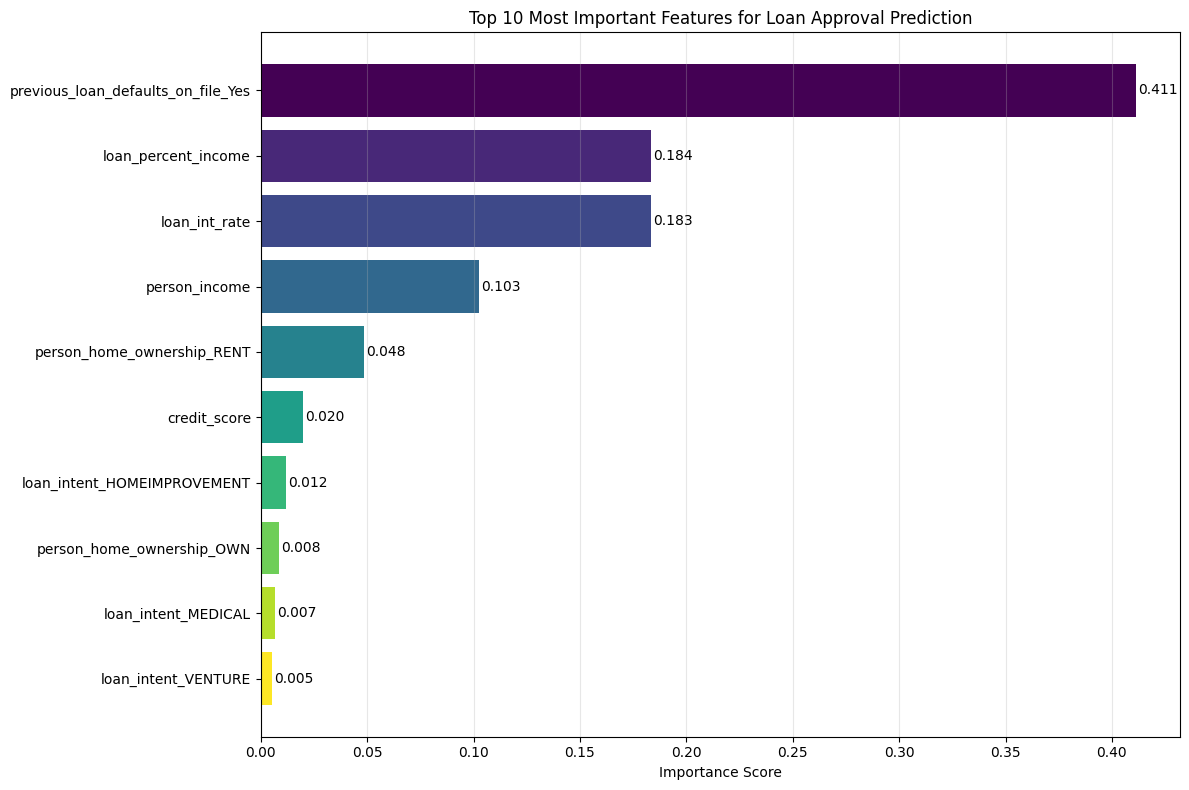

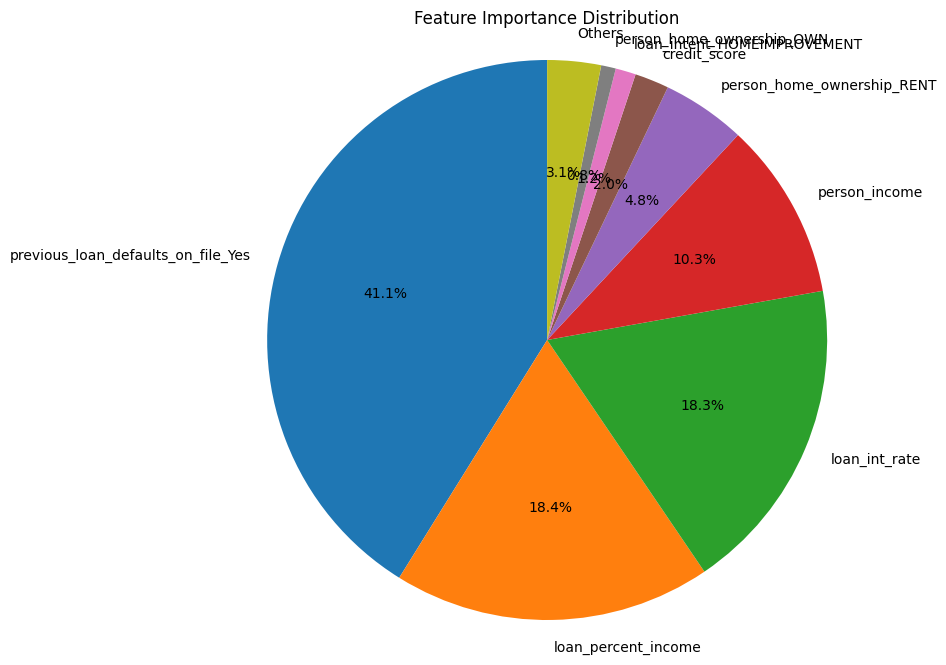

In [ ]:
# Visualize feature importance
plt.figure(figsize=(12, 8))

# Plotting top 10 features
top_10_features = importance_df.head(10)
colors = plt.cm.viridis(np.linspace(0, 1, len(top_10_features)))

plt.barh(range(len(top_10_features)), top_10_features['importance'], color=colors)
plt.yticks(range(len(top_10_features)), top_10_features['feature'])
plt.xlabel('Importance Score')
plt.title('Top 10 Most Important Features for Loan Approval Prediction')
plt.gca().invert_yaxis()

# Adding value labels on bars
for i, v in enumerate(top_10_features['importance']):
    plt.text(v + 0.001, i, f'{v:.3f}', va='center', ha='left')

plt.tight_layout()
plt.grid(axis='x', alpha=0.3)
plt.show()

# Feature importance pie chart (top 8 features)
plt.figure(figsize=(10, 8))
top_8 = importance_df.head(8)
others_importance = importance_df.iloc[8:]['importance'].sum()

if others_importance > 0:
    plot_data = list(top_8['importance']) + [others_importance]
    plot_labels = list(top_8['feature']) + ['Others']
else:
    plot_data = list(top_8['importance'])
    plot_labels = list(top_8['feature'])

plt.pie(plot_data, labels=plot_labels, autopct='%1.1f%%', startangle=90)
plt.title('Feature Importance Distribution')
plt.axis('equal')
plt.show()

## 10. Model Complexity Analysis

In [ ]:
# Model complexity analysis
tree_depth = best_model.get_depth()
n_leaves = best_model.get_n_leaves()
n_nodes = best_model.tree_.node_count

print(f"🌳 DECISION TREE STRUCTURE ANALYSIS:")
print(f"" + "=" * 40)
print(f"  Tree Depth: {tree_depth} levels")
print(f"  Number of Leaves: {n_leaves}")
print(f"  Total Nodes: {n_nodes}")

# Assesing tree complexity
if tree_depth > 20:
    print(f"\n⚠️  Warning: Tree is very deep (depth={tree_depth})")
    print(f"   Consider pruning or limiting max_depth to prevent overfitting.")
elif tree_depth < 5:
    print(f"\n✅ Tree is relatively shallow (depth={tree_depth})")
    print(f"   Model is simple and highly interpretable.")
else:
    print(f"\n✅ Tree depth is reasonable (depth={tree_depth})")
    print(f"   Good balance between complexity and interpretability.")

# Interpretability score
interpretability_score = max(0, 10 - tree_depth) + (10 if n_leaves < 20 else 5)
print(f"\n📊 Interpretability Score: {interpretability_score}/20")
if interpretability_score >= 15:
    print(f"   🌟 Highly interpretable model - easy to explain to stakeholders")
elif interpretability_score >= 10:
    print(f"   ✅ Moderately interpretable - reasonable for business use")
else:
    print(f"   ⚠️  Complex model - may be difficult to interpret")

🌳 DECISION TREE STRUCTURE ANALYSIS:
  Tree Depth: 10 levels
  Number of Leaves: 171
  Total Nodes: 341

✅ Tree depth is reasonable (depth=10)
   Good balance between complexity and interpretability.

📊 Interpretability Score: 5/20
   ⚠️  Complex model - may be difficult to interpret


## 11. Performance Visualizations

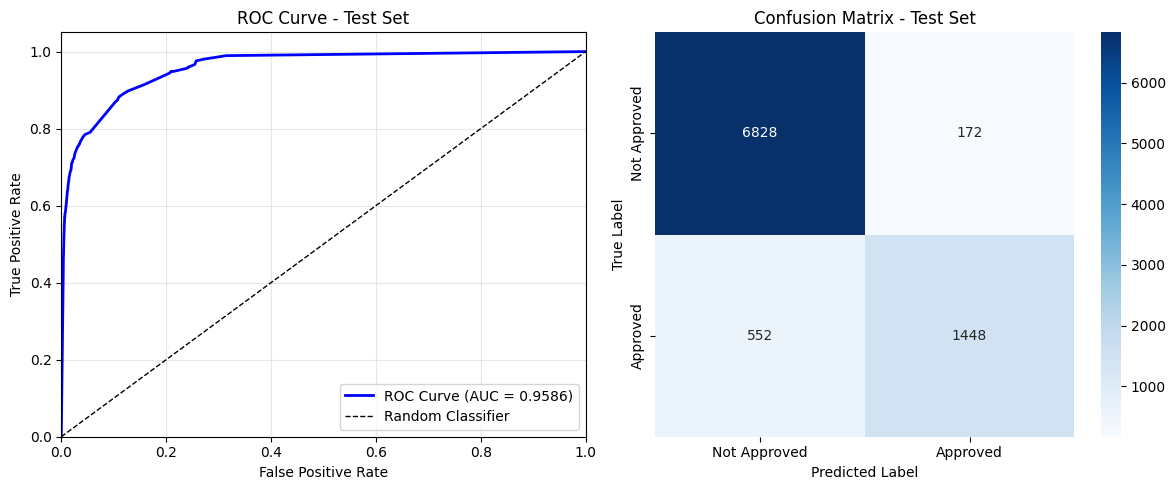

In [ ]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(12, 5))

# ROC Curve
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC = {test_metrics["roc_auc"]:.4f})', color='blue')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Test Set')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

# Confusion Matrix Heatmap
plt.subplot(1, 2, 2)
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Not Approved', 'Approved'],
            yticklabels=['Not Approved', 'Approved'])
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix - Test Set')

plt.tight_layout()
plt.show()

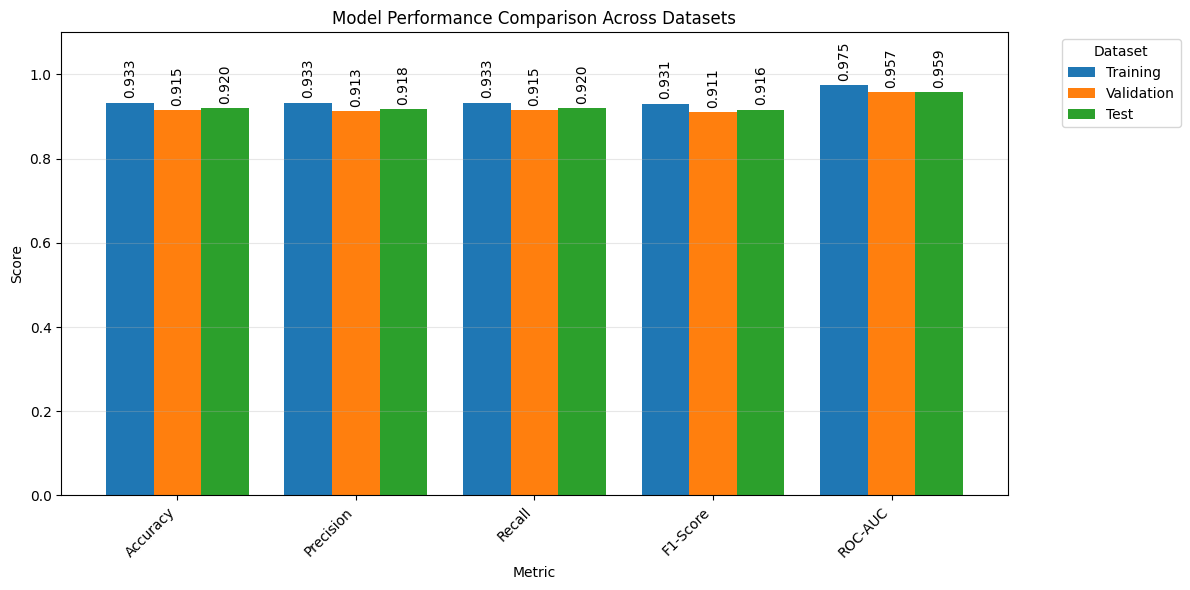


📊 Performance Summary:
           Training  Validation    Test
Accuracy     0.9333      0.9147  0.9196
Precision    0.9332      0.9130  0.9182
Recall       0.9333      0.9147  0.9196
F1-Score     0.9307      0.9113  0.9164
ROC-AUC      0.9748      0.9574  0.9586


In [ ]:
# Performance comparison across datasets
metrics_comparison = pd.DataFrame({
    'Training': [train_metrics['accuracy'], train_metrics['precision'],
                train_metrics['recall'], train_metrics['f1'], train_metrics['roc_auc']],
    'Validation': [val_metrics['accuracy'], val_metrics['precision'],
                  val_metrics['recall'], val_metrics['f1'], val_metrics['roc_auc']],
    'Test': [test_metrics['accuracy'], test_metrics['precision'],
            test_metrics['recall'], test_metrics['f1'], test_metrics['roc_auc']]
}, index=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'])

plt.figure(figsize=(12, 6))
ax = metrics_comparison.plot(kind='bar', ax=plt.gca(), width=0.8)
plt.title('Model Performance Comparison Across Datasets')
plt.ylabel('Score')
plt.xlabel('Metric')
plt.ylim([0, 1.1])
plt.legend(title='Dataset', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', rotation=90, padding=3)

plt.tight_layout()
plt.show()

print("\n📊 Performance Summary:")
print(metrics_comparison.round(4))

## 12. Prediction Function for New Applications

In [ ]:
def predict_loan_approval(model, preprocessor, new_data):
    """
    Predict loan approval for new applications using one-hot encoding

    Parameters:
    -----------
    model : trained DecisionTreeClassifier
    preprocessor : fitted ColumnTransformer (with StandardScaler and OneHotEncoder)
    new_data : dict with application features

    Returns:
    --------
    prediction : int (0=rejected, 1=approved)
    probability : float (approval probability)
    confidence : str (High/Medium/Low)
    """
    try:
        # Creating DataFrame from input
        df_new = pd.DataFrame([new_data])

        # Ensuring columns are in correct order
        df_new = df_new[categorical_cols + numerical_cols]

        # Applying preprocessing (scaling + one-hot encoding)
        df_processed = preprocessor.transform(df_new)

        # Making prediction
        prediction = model.predict(df_processed)[0]
        probability = model.predict_proba(df_processed)[0, 1]

        # Determining confidence level
        confidence_score = abs(probability - 0.5)
        if confidence_score > 0.3:
            confidence = "High"
        elif confidence_score > 0.15:
            confidence = "Medium"
        else:
            confidence = "Low"

        return prediction, probability, confidence

    except Exception as e:
        print(f"❌ Error in prediction: {str(e)}")
        return None, None, None

In [ ]:
# Example loan applications for testing
example_applications = [
    {
        'name': 'High-Income Professional',
        'data': {
            'person_gender': 'male',
            'person_education': 'Master',
            'person_home_ownership': 'OWN',
            'loan_intent': 'HOMEIMPROVEMENT',
            'previous_loan_defaults_on_file': 'No',
            'person_age': 30,
            'person_income': 95000,
            'person_emp_exp': 6,
            'loan_amnt': 25000,
            'loan_int_rate': 10.5,
            'loan_percent_income': 0.26,
            'cb_person_cred_hist_length': 7,
            'credit_score': 720
        }
    },
    {
        'name': 'Young Graduate',
        'data': {
            'person_gender': 'female',
            'person_education': 'Bachelor',
            'person_home_ownership': 'RENT',
            'loan_intent': 'EDUCATION',
            'previous_loan_defaults_on_file': 'No',
            'person_age': 24,
            'person_income': 45000,
            'person_emp_exp': 1,
            'loan_amnt': 15000,
            'loan_int_rate': 13.2,
            'loan_percent_income': 0.33,
            'cb_person_cred_hist_length': 2,
            'credit_score': 640
        }
    },
    {
        'name': 'Previous Defaulter',
        'data': {
            'person_gender': 'male',
            'person_education': 'High School',
            'person_home_ownership': 'RENT',
            'loan_intent': 'DEBTCONSOLIDATION',
            'previous_loan_defaults_on_file': 'Yes',
            'person_age': 35,
            'person_income': 32000,
            'person_emp_exp': 8,
            'loan_amnt': 18000,
            'loan_int_rate': 16.8,
            'loan_percent_income': 0.56,
            'cb_person_cred_hist_length': 12,
            'credit_score': 580
        }
    }
]

print("EXAMPLE LOAN PREDICTIONS:")
print("=" * 50)

for i, app in enumerate(example_applications, 1):
    print(f"\n{i}. {app['name']}:")

    # Showing key application details
    key_details = ['person_income', 'credit_score', 'loan_amnt',
                  'loan_percent_income', 'previous_loan_defaults_on_file']
    print("   Key Details:")
    for detail in key_details:
        print(f"     {detail}: {app['data'][detail]}")

    # Making prediction using updated function
    pred, prob, conf = predict_loan_approval(best_model, preprocessor, app['data'])

    if pred is not None:
        decision = "✅ APPROVED" if pred == 1 else "❌ NOT APPROVED"
        print(f"   Prediction: {decision}")
        print(f"   Approval Probability: {prob:.2%}")
        print(f"   Confidence Level: {conf}")
    else:
        print("   ❌ Failed to make prediction")

    print("-" * 30)

EXAMPLE LOAN PREDICTIONS:

1. High-Income Professional:
   Key Details:
     person_income: 95000
     credit_score: 720
     loan_amnt: 25000
     loan_percent_income: 0.26
     previous_loan_defaults_on_file: No
   Prediction: ❌ NOT APPROVED
   Approval Probability: 12.50%
   Confidence Level: High
------------------------------

2. Young Graduate:
   Key Details:
     person_income: 45000
     credit_score: 640
     loan_amnt: 15000
     loan_percent_income: 0.33
     previous_loan_defaults_on_file: No
   Prediction: ✅ APPROVED
   Approval Probability: 100.00%
   Confidence Level: High
------------------------------

3. Previous Defaulter:
   Key Details:
     person_income: 32000
     credit_score: 580
     loan_amnt: 18000
     loan_percent_income: 0.56
     previous_loan_defaults_on_file: Yes
   Prediction: ❌ NOT APPROVED
   Approval Probability: 0.00%
   Confidence Level: High
------------------------------


## 13. Saving Model & Preprocessing Objects

In [ ]:
import pickle

# Saving all model artifacts including preprocessor
model_files = {
    'decision_tree_model.pkl': best_model,
    'preprocessor.pkl': preprocessor,  # Saving the preprocessor instead of separate scaler and encoders
    'feature_names.pkl': all_feature_names,
    'categorical_cols.pkl': categorical_cols,
    'numerical_cols.pkl': numerical_cols
}

print("💾 Saving model artifacts...")
for filename, obj in model_files.items():
    with open(filename, 'wb') as f:
        pickle.dump(obj, f)
    print(f"✅ Saved: {filename}")

print(f"\nAll model artifacts saved successfully!")
print(f"\nTo load and use the model later:")
print("""
import pickle

# Load artifacts
with open('decision_tree_model.pkl', 'rb') as f:
    model = pickle.load(f)
with open('preprocessor.pkl', 'rb') as f:
    preprocessor = pickle.load(f)
with open('categorical_cols.pkl', 'rb') as f:
    categorical_cols = pickle.load(f)
with open('numerical_cols.pkl', 'rb') as f:
    numerical_cols = pickle.load(f)

# Make predictions
new_data = {...}  # Your new application data
df_new = pd.DataFrame([new_data])[categorical_cols + numerical_cols]
df_processed = preprocessor.transform(df_new)
prediction = model.predict(df_processed)[0]
probability = model.predict_proba(df_processed)[0, 1]
""")

💾 Saving model artifacts...
✅ Saved: decision_tree_model.pkl
✅ Saved: preprocessor.pkl
✅ Saved: feature_names.pkl
✅ Saved: categorical_cols.pkl
✅ Saved: numerical_cols.pkl

All model artifacts saved successfully!

To load and use the model later:

import pickle

# Load artifacts
with open('decision_tree_model.pkl', 'rb') as f:
    model = pickle.load(f)
with open('preprocessor.pkl', 'rb') as f:
    preprocessor = pickle.load(f)
with open('categorical_cols.pkl', 'rb') as f:
    categorical_cols = pickle.load(f)
with open('numerical_cols.pkl', 'rb') as f:
    numerical_cols = pickle.load(f)

# Make predictions
new_data = {...}  # Your new application data
df_new = pd.DataFrame([new_data])[categorical_cols + numerical_cols]
df_processed = preprocessor.transform(df_new)
prediction = model.predict(df_processed)[0]
probability = model.predict_proba(df_processed)[0, 1]



## 14. Final Model Summary & Insights

In [ ]:
# Create comprehensive summary
print("🏆 FINAL MODEL SUMMARY")
print("=" * 50)

print(f"\n📊 Dataset Information:")
print(f"  Total Records: {len(df):,}")
print(f"  Features: {df.shape[1] - 1}")
print(f"  Class Imbalance Ratio: {imbalance_ratio:.2f}:1")

print(f"\n🎯 Best Model Configuration:")
print(f"  Algorithm: Decision Tree Classifier")
for param, value in best_params.items():
    print(f"  {param}: {value}")

print(f"\n📈 Performance Metrics:")
performance_summary = pd.DataFrame({
    'Training': [f"{train_metrics['accuracy']:.4f}", f"{train_metrics['f1']:.4f}", f"{train_metrics['roc_auc']:.4f}"],
    'Validation': [f"{val_metrics['accuracy']:.4f}", f"{val_metrics['f1']:.4f}", f"{val_metrics['roc_auc']:.4f}"],
    'Test': [f"{test_metrics['accuracy']:.4f}", f"{test_metrics['f1']:.4f}", f"{test_metrics['roc_auc']:.4f}"]
}, index=['Accuracy', 'F1-Score', 'ROC-AUC'])

print(performance_summary)

print(f"\n🌳 Model Complexity:")
print(f"  Tree Depth: {tree_depth} levels")
print(f"  Number of Leaves: {n_leaves}")
print(f"  Total Nodes: {n_nodes}")
print(f"  Interpretability: {'High' if tree_depth < 8 else 'Medium' if tree_depth < 15 else 'Low'}")

print(f"\n🔍 Top 3 Most Important Features:")
for idx, (i, row) in enumerate(importance_df.head(3).iterrows(), 1):
    print(f"  {idx}. {row['feature']}: {row['importance']:.4f} ({row['importance']*100:.2f}%)")

print(f"\n⚖️  Class Imbalance Handling:")
print(f"  ✓ Balanced class weights applied")
print(f"  ✓ Stratified train-test splits used")
print(f"  ✓ F1-score optimized (better for imbalanced data)")
print(f"  ✓ Comprehensive evaluation with multiple metrics")

🏆 FINAL MODEL SUMMARY

📊 Dataset Information:
  Total Records: 45,000
  Features: 13
  Class Imbalance Ratio: 3.50:1

🎯 Best Model Configuration:
  Algorithm: Decision Tree Classifier
  class_weight: None
  criterion: gini
  max_depth: 10
  min_samples_leaf: 1
  min_samples_split: 10

📈 Performance Metrics:
         Training Validation    Test
Accuracy   0.9333     0.9147  0.9196
F1-Score   0.9307     0.9113  0.9164
ROC-AUC    0.9748     0.9574  0.9586

🌳 Model Complexity:
  Tree Depth: 10 levels
  Number of Leaves: 171
  Total Nodes: 341
  Interpretability: Medium

🔍 Top 3 Most Important Features:
  1. previous_loan_defaults_on_file_Yes: 0.4114 (41.14%)
  2. loan_percent_income: 0.1835 (18.35%)
  3. loan_int_rate: 0.1832 (18.32%)

⚖️  Class Imbalance Handling:
  ✓ Balanced class weights applied
  ✓ Stratified train-test splits used
  ✓ F1-score optimized (better for imbalanced data)
  ✓ Comprehensive evaluation with multiple metrics


## 10. Decision Tree Visualization

In [ ]:
# Getting tree information
tree_depth = best_model.get_depth()
n_leaves = best_model.get_n_leaves()
n_nodes = best_model.tree_.node_count

print(f"Tree Structure Information:")
print(f"  Tree Depth: {tree_depth} levels")
print(f"  Number of Leaves: {n_leaves}")
print(f"  Total Nodes: {n_nodes}")

# VISUALIZATION 1: Full Decision Tree
print("\nGenerating full decision tree visualization...")
plt.figure(figsize=(25, 15))
plot_tree(
    best_model,
    feature_names=all_feature_names,
    class_names=['Not Approved', 'Approved'],
    filled=True,
    rounded=True,
    fontsize=10,
    proportion=True,
    precision=2
)
plt.title(f'Complete Decision Tree for Loan Approval Prediction\n'
          f'Depth: {tree_depth} | Leaves: {n_leaves} | Nodes: {n_nodes}',
          fontsize=16, pad=20, weight='bold')
plt.tight_layout()
plt.savefig('decision_tree_full.png', dpi=300, bbox_inches='tight')
print("✅ Saved: decision_tree_full.png")
plt.show()

# VISUALIZATION 2: Simplified Tree (Max Depth 3 for readability)
print("\nGenerating simplified tree visualization (max_depth=3)...")
plt.figure(figsize=(20, 12))
plot_tree(
    best_model,
    feature_names=all_feature_names,
    class_names=['Not Approved', 'Approved'],
    filled=True,
    rounded=True,
    fontsize=12,
    max_depth=3,  # Limit depth for readability
    proportion=True,
    precision=2
)
plt.title('Simplified Decision Tree (Top 3 Levels)\nFor Better Readability',
          fontsize=16, pad=20, weight='bold')
plt.tight_layout()
plt.savefig('decision_tree_simplified.png', dpi=300, bbox_inches='tight')
print("✅ Saved: decision_tree_simplified.png")
plt.show()

# VISUALIZATION 3: High-Resolution Tree with Custom Styling
print("\nGenerating high-resolution tree with model parameters...")
fig, ax = plt.subplots(figsize=(30, 20))
plot_tree(
    best_model,
    feature_names=all_feature_names,
    class_names=['Not Approved', 'Approved'],
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax,
    proportion=True,
    precision=3,
    impurity=True  # Show gini/entropy values
)

# Add custom title with model parameters
title_text = f'Decision Tree for Loan Approval Prediction\n'
title_text += f'Criterion: {best_params["criterion"]} | '
title_text += f'Max Depth: {best_params["max_depth"]} | '
title_text += f'Min Samples Split: {best_params["min_samples_split"]} | '
title_text += f'Min Samples Leaf: {best_params["min_samples_leaf"]}\n'
title_text += f'Tree Depth: {tree_depth} | Leaves: {n_leaves} | Total Nodes: {n_nodes}'

ax.set_title(title_text, fontsize=18, pad=30, weight='bold')

plt.tight_layout()
plt.savefig('decision_tree_highres.png', dpi=600, bbox_inches='tight')
print("Saved: decision_tree_highres.png (high resolution - 600 DPI)")
plt.show()

print("\n" + "="*60)
print("TREE VISUALIZATION COMPLETE!")
print("="*60)
print("Generated files:")
print("  1. decision_tree_full.png")
print("  2. decision_tree_simplified.png")
print("  3. decision_tree_highres.png")